**#PROBLEM STATEMENT:Segment the customer based on age, annual income, spending score** our companys goal is to customer groups for personalized target marketing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder



# checking for data and converted csv into dataframe

In [ ]:
df=pd.read_csv("/content/Mall_customer.csv")

In [ ]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# all the information regarding columns with data type

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
df.shape

(200, 5)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


# Finding any null values

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# looking for any duplicate data points

In [ ]:
df.duplicated().sum()

np.int64(0)

## we can remove duplicate value by drop duplicated data points which reduce redundancy

# we remove unique columns by dropping columns

In [ ]:
df.drop(columns='CustomerID',inplace=True)

# mapping for Gender column

In [ ]:
df["Gender"]=df["Gender"].map({'Male':1,'Female':0})

In [ ]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [ ]:
def remove_outliers(df,columns):
  q1=df[columns].quantile(0.25)
  q3=df[columns].quantile(0.75)
  IQR=q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR
  df=df[(df[columns]>=lower_bound) & (df[columns]<=upper_bound)]
  return df


In [ ]:
for col in df.columns:
  df=remove_outliers(df,col)

In [ ]:
df.shape

(198, 4)

# pairplot making

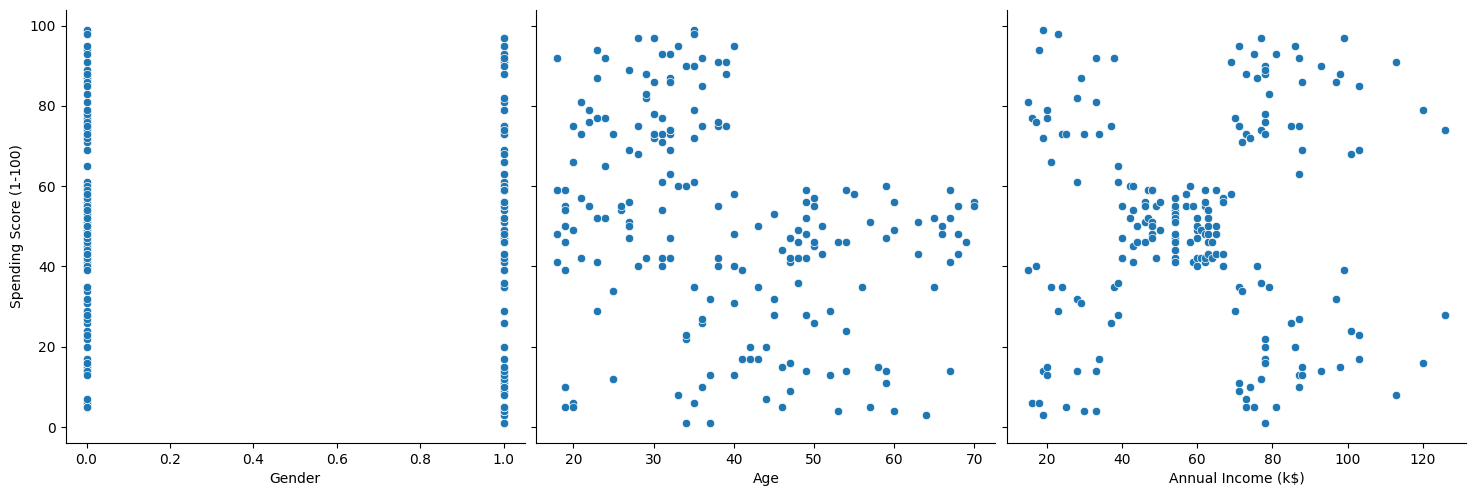

In [ ]:
sns.pairplot(df,x_vars=['Gender','Age','Annual Income (k$)'],y_vars='Spending Score (1-100)',height=5,aspect=1)

# from above pairplot we evident pattern between
1.Spencing_score vs age
2.Spending_score vs Annual_income

In [ ]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

In [ ]:
km=KMeans(n_clusters=7)

In [ ]:
km

KMeans(n_clusters=7)

# We get two Parameters for KMeans Models i.e.
1.km.inertia_=SSE of that model
2.km.cluster_centers=Stores the values of centriods

In [ ]:
y_pred=km.fit_predict(X)

In [ ]:
y_pred

array([3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 2,
       3, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 0, 5, 0, 5, 0, 5, 0, 5,
       0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 2, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5,
       0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5,
       0, 5, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4],
      dtype=int32)

# Lets visualize the output cluster

In [ ]:
plt.scatter(X.iloc['y_pred'==0,0],X.iloc['y_pred'==0,1],s=30,c='green',label='cluster1')
plt.scatter(X.iloc['y_pred'==1,0],X.iloc['y_pred'==1,1],s=30,c='blue',label='cluster2')
plt.scatter(X.iloc['y_pred'==2,0],X.iloc['y_pred'==2,1],s=30,c='red',label='cluster3')
plt.scatter(X.iloc['y_pred'==3,0],X.iloc['y_pred'==3,1],s=30,c='magenta',label='cluster4')
plt.scatter(X.iloc['y_pred'==4,0],X.iloc['y_pred'==4,1],s=30,c='cyan',label='cluster5')
plt.scatter(X.iloc['y_pred'==5,0],X.iloc['y_pred'==5,1],s=30,c='black',label='cluster6')
plt.scatter(X.iloc['y_pred'==6,0],X.iloc['y_pred'==6,1],s=30,c='orange',label='cluster7')
plt.scatter(km.cluster_centers[:,0],km.cluster_centers[:,1],s=100,c='maroon',label='centriods')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

#finding optimal value of k using elbow method

In [ ]:
sse=[] #creating list for sum of sequre error(sse)

In [ ]:
for k in range(1,11):
  km=KMeans(n_clusters=k)
  km.fit(X)
  sse.append(km.inertia_)


In [ ]:
sse

# plot elbowchart of k vs sse

In [ ]:
plt.plot(range(1,11),sse)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

## Optimal value for k=6 , lets plot sactter plot for it

In [ ]:
km=KMeans(n_clusters=6)

In [ ]:
km

In [ ]:
y_pred=km.fit_predict(df)

In [ ]:
y_pred

In [ ]:
colors = ['green', 'blue', 'red', 'magenta', 'cyan', 'black']
for i in range(6):
    plt.scatter(df[y_pred == i].iloc[:, 2], df[y_pred == i].iloc[:, 3], s=30, c=colors[i], label=f'cluster{i+1}')

plt.scatter(km.cluster_centers_[:, 2], km.cluster_centers_[:, 3], s=100, c='maroon', label='centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
X=df[["Age","Spending Score (1-100)"]]

In [ ]:
km=KMeans(n_clusters=6)

In [ ]:
km

In [ ]:
y_pread=km.fit_predict(X)

In [ ]:
colors = ['green', 'blue', 'red', 'magenta']
for i in range(4):
    plt.scatter(X[y_pread == i].iloc[:, 0], X[y_pread == i].iloc[:, 1], s=30, c=colors[i], label=f'cluster{i+1}')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=100, c='maroon', label='centroids')
plt.title('Clusters of customers based on Age and Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
sse=[]

In [ ]:
for i in range(1,11):
  km=KMeans(n_clusters=k)
  km.fit(X)
  sse.append(km.inertia_)



In [ ]:
sse

In [ ]:
plt.plot(range(1,11),sse)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [ ]:
km=KMeans(n_clusters=5)

In [ ]:
km

In [ ]:
y_pread=km.fit_predict(X)

In [ ]:
y_pread

In [ ]:
colors = ['green', 'blue', 'red', 'magenta']
for i in range(4):
    plt.scatter(X[y_pread == i].iloc[:, 0], X[y_pread == i].iloc[:, 1], s=30, c=colors[i], label=f'cluster{i+1}')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=100, c='maroon', label='centroids')
plt.title('Clusters of customers based on Age and Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()